In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

In [16]:
# 元データ
# 自分のファイル名に合わせてください
BASE_FILE = "決定版.csv"

# 第3週で保存したタイプ分類データ
TYPE_FILE = "week3_type_classification_re24_wpa.csv"

# 元データ読み込み
encodings = ["utf-8-sig", "utf-8", "cp932", "shift_jis"]

for enc in encodings:
    try:
        df = pd.read_csv(BASE_FILE, encoding=enc)
        print("元データ読み込み成功:", enc)
        break
    except UnicodeDecodeError:
        print("失敗:", enc)

# タイプ分類データ読み込み
type_df = pd.read_csv(TYPE_FILE, encoding="utf-8-sig")

print("元データ行数:", len(df))
print("タイプ分類データ行数:", len(type_df))

print(df.columns.tolist())
type_df.head()

元データ読み込み成功: utf-8-sig
元データ行数: 7338
タイプ分類データ行数: 25
['日付', '球団', '対戦相手', '打者名', '打順', 'イニング', '表裏', 'イニング内打席番号', '自チーム打席前得点', '相手チーム打席前得点', '打席前点差', '打席前アウト数', '打席前走者状況コード', '打席前一塁走者', '打席前二塁走者', '打席前三塁走者', '打席前状況コード', '打席結果', 'この打席得点数', '打点', '自チーム打席後得点', '相手チーム打席後得点', '打席後点差', '打席後アウト数', '打席後走者状況コード', '打席後一塁走者', '打席後二塁走者', '打席後三塁走者', '打席後状況コード', '得点圏フラグ', '打者走者進塁先', '打席前RE', '打席後RE', 'RE24', '打席前WE', '打席後WE', 'WPA', 'WEサンプル数_前', 'WEサンプル数_後']


,球団,打者名,PA,打点合計,RE24合計,WPA合計,打点/PA,RE24/PA,WPA/PA,打点順位,RE24順位,WPA順位,打点/PA順位,RE24/PA順位,WPA/PA順位,WPA評価上昇,タイプ
0,阪神,佐藤 輝明,544,91,47.723,3.238965,0.167279,0.087726,0.005954,1,1,6,4,4,10,-5,総合型
1,西武,ネビン,491,54,21.654,0.468037,0.109980,0.044102,0.000953,2,5,18,13,11,19,-16,得点貢献型
2,中日,細川 成也,313,43,19.930,3.654191,0.137380,0.063674,0.011675,5,6,5,8,8,5,0,総合型
3,オリックス,杉本 裕太郎,308,29,-8.236,0.965217,0.094156,-0.026740,0.003134,10,25,13,20,22,15,-3,勝利貢献型
4,ソフトバンク,山川 穂高,289,35,0.287,0.849737,0.121107,0.000993,0.002940,8,18,14,10,18,16,-6,その他


In [17]:
team_col = "球団"
batter_col = "打者名"
result_col = "打席結果"
risp_col = "得点圏フラグ"

print("球団列:", team_col)
print("打者列:", batter_col)
print("打席結果列:", result_col)
print("得点圏フラグ列:", risp_col)

球団列: 球団
打者列: 打者名
打席結果列: 打席結果
得点圏フラグ列: 得点圏フラグ


In [18]:
def classify_batting_result(result):
    result = str(result)

    # 四球・敬遠・死球
    is_bb = result in ["四球", "故意四"]
    is_hbp = result == "死球"

    # 犠飛・犠打
    is_sf = "犠飛" in result
    is_sh = "犠打" in result

    # 安打判定
    is_hr = "本" in result
    is_3b = "３" in result
    is_2b = "２" in result
    is_1b = "安" in result

    is_hit = is_1b or is_2b or is_3b or is_hr

    # 塁打
    if is_hr:
        tb = 4
    elif is_3b:
        tb = 3
    elif is_2b:
        tb = 2
    elif is_1b:
        tb = 1
    else:
        tb = 0

    # 打数
    # 四球・死球・犠飛・犠打は打数に含めない
    is_ab = not (is_bb or is_hbp or is_sf or is_sh)

    return pd.Series({
        "AB": int(is_ab),
        "H": int(is_hit),
        "TB": tb,
        "BB": int(is_bb),
        "HBP": int(is_hbp),
        "SF": int(is_sf),
        "SH": int(is_sh)
    })


batting_parts = df[result_col].apply(classify_batting_result)
df_ops = pd.concat([df, batting_parts], axis=1)

df_ops[[team_col, batter_col, result_col, "AB", "H", "TB", "BB", "HBP", "SF", "SH"]].head(20)

,球団,打者名,打席結果,AB,H,TB,BB,HBP,SF,SH
0,巨人,岡本 和真,三飛,1,0,0,0,0,0,0
1,ヤクルト,サンタナ,空三振,1,0,0,0,0,0,0
2,巨人,岡本 和真,空三振,1,0,0,0,0,0,0
3,ヤクルト,サンタナ,左安,1,1,1,0,0,0,0
4,ヤクルト,サンタナ,左本,1,1,4,0,0,0,0
5,巨人,岡本 和真,二ゴロ,1,0,0,0,0,0,0
6,ヤクルト,サンタナ,空三振,1,0,0,0,0,0,0
7,巨人,岡本 和真,一飛,1,0,0,0,0,0,0
8,巨人,岡本 和真,左安,1,1,1,0,0,0,0
9,中日,石川 昂弥,左飛,1,0,0,0,0,0,0


In [19]:
ops_summary = (
    df_ops.groupby([team_col, batter_col])
    .agg(
        PA=(batter_col, "count"),
        AB=("AB", "sum"),
        H=("H", "sum"),
        TB=("TB", "sum"),
        BB=("BB", "sum"),
        HBP=("HBP", "sum"),
        SF=("SF", "sum"),
        SH=("SH", "sum")
    )
    .reset_index()
)

# 出塁率 OBP = (H + BB + HBP) / (AB + BB + HBP + SF)
ops_summary["OBP"] = (
    (ops_summary["H"] + ops_summary["BB"] + ops_summary["HBP"]) /
    (ops_summary["AB"] + ops_summary["BB"] + ops_summary["HBP"] + ops_summary["SF"])
)

# 長打率 SLG = TB / AB
ops_summary["SLG"] = ops_summary["TB"] / ops_summary["AB"]

# OPS
ops_summary["OPS"] = ops_summary["OBP"] + ops_summary["SLG"]

ops_summary = ops_summary.replace([np.inf, -np.inf], np.nan)

ops_summary.sort_values("OPS", ascending=False).head(20)

,球団,打者名,PA,AB,H,TB,BB,HBP,SF,SH,OBP,SLG,OPS
42,ソフトバンク,笹川 吉康,1,1,1,4,0,0,0,0,1.000000,4.000000,5.000000
135,楽天,小森 航大郎,1,1,1,2,0,0,0,0,1.000000,2.000000,3.000000
161,阪神,楠本 泰史,1,1,1,2,0,0,0,0,1.000000,2.000000,3.000000
152,西武,元山 飛優,2,2,2,3,0,0,0,0,1.000000,1.500000,2.500000
136,楽天,小郷 裕哉,2,2,1,4,0,0,0,0,0.500000,2.000000,2.500000
3,DeNA,三森 大貴,3,2,2,2,1,0,0,0,1.000000,1.000000,2.000000
85,中日,駿太,1,1,1,1,0,0,0,0,1.000000,1.000000,2.000000
27,オリックス,若月 健矢,1,1,1,1,0,0,0,0,1.000000,1.000000,2.000000
64,ロッテ,小川 龍成,2,1,1,1,1,0,0,0,1.000000,1.000000,2.000000
78,中日,大島 洋平,1,1,1,1,0,0,0,0,1.000000,1.000000,2.000000


In [20]:
risp_df = df_ops[df_ops[risp_col] == 1].copy()

risp_summary = (
    risp_df.groupby([team_col, batter_col])
    .agg(
        得点圏PA=(batter_col, "count"),
        得点圏AB=("AB", "sum"),
        得点圏H=("H", "sum"),
        得点圏TB=("TB", "sum"),
        得点圏BB=("BB", "sum"),
        得点圏HBP=("HBP", "sum"),
        得点圏SF=("SF", "sum")
    )
    .reset_index()
)

risp_summary["得点圏OBP"] = (
    (risp_summary["得点圏H"] + risp_summary["得点圏BB"] + risp_summary["得点圏HBP"]) /
    (risp_summary["得点圏AB"] + risp_summary["得点圏BB"] + risp_summary["得点圏HBP"] + risp_summary["得点圏SF"])
)

risp_summary["得点圏SLG"] = risp_summary["得点圏TB"] / risp_summary["得点圏AB"]

risp_summary["得点圏OPS"] = risp_summary["得点圏OBP"] + risp_summary["得点圏SLG"]

risp_summary = risp_summary.replace([np.inf, -np.inf], np.nan)

risp_summary.sort_values("得点圏OPS", ascending=False).head(20)

,球団,打者名,得点圏PA,得点圏AB,得点圏H,得点圏TB,得点圏BB,得点圏HBP,得点圏SF,得点圏OBP,得点圏SLG,得点圏OPS
32,ソフトバンク,笹川 吉康,1,1,1,4,0,0,0,1.000000,4.000000,5.000000
22,オリックス,西野 真弘,1,1,1,3,0,0,0,1.000000,3.000000,4.000000
98,日本ハム,石井 一成,1,1,1,2,0,0,0,1.000000,2.000000,3.000000
110,楽天,石原 彪,1,1,1,1,0,0,0,1.000000,1.000000,2.000000
44,ヤクルト,西村 瑠伊斗,1,1,1,1,0,0,0,1.000000,1.000000,2.000000
3,DeNA,三森 大貴,2,1,1,1,1,0,0,1.000000,1.000000,2.000000
92,日本ハム,五十幡 亮汰,1,1,1,1,0,0,0,1.000000,1.000000,2.000000
27,ソフトバンク,川瀬 晃,1,1,1,1,0,0,0,1.000000,1.000000,2.000000
96,日本ハム,清宮 幸太郎,1,1,1,1,0,0,0,1.000000,1.000000,2.000000
20,オリックス,若月 健矢,1,1,1,1,0,0,0,1.000000,1.000000,2.000000


In [21]:
analysis_df = type_df.merge(
    ops_summary[[team_col, batter_col, "OPS", "OBP", "SLG", "AB", "H", "TB", "BB", "HBP", "SF"]],
    on=[team_col, batter_col],
    how="left"
)

analysis_df = analysis_df.merge(
    risp_summary[[team_col, batter_col, "得点圏PA", "得点圏OPS", "得点圏OBP", "得点圏SLG"]],
    on=[team_col, batter_col],
    how="left"
)

analysis_df[
    [team_col, batter_col, "タイプ", "PA", "打点合計", "RE24合計", "WPA合計",
     "OPS", "得点圏OPS", "得点圏PA"]
].head(20)

,球団,打者名,タイプ,PA,打点合計,RE24合計,WPA合計,OPS,得点圏OPS,得点圏PA
0,阪神,佐藤 輝明,総合型,544,91,47.723,3.238965,0.931997,1.032164,169
1,西武,ネビン,得点貢献型,491,54,21.654,0.468037,0.803850,0.829255,120
2,中日,細川 成也,総合型,313,43,19.930,3.654191,0.849744,0.907851,94
3,オリックス,杉本 裕太郎,勝利貢献型,308,29,-8.236,0.965217,0.670948,0.508399,94
4,ソフトバンク,山川 穂高,その他,289,35,0.287,0.849737,0.672496,0.552353,100
5,巨人,岡本 和真,総合型,280,49,28.686,4.366410,1.014286,0.904808,80
6,ヤクルト,オスナ,その他,273,30,3.214,0.736590,0.641026,0.779647,77
7,広島,末包 昇大,得点貢献型,267,40,10.932,-0.075041,0.691615,0.897209,74
8,DeNA,牧 秀悟,勝利貢献型,243,27,8.321,5.049012,0.786996,0.845533,62
9,ヤクルト,村上 宗隆,総合型,222,47,31.171,4.020346,1.053153,1.011921,62


In [22]:
type_ops_summary = (
    analysis_df.groupby("タイプ")
    .agg(
        人数=("タイプ", "count"),
        平均PA=("PA", "mean"),
        平均OPS=("OPS", "mean"),
        平均得点圏OPS=("得点圏OPS", "mean"),
        平均得点圏PA=("得点圏PA", "mean"),
        平均RE24=("RE24合計", "mean"),
        平均WPA=("WPA合計", "mean"),
        平均RE24_PA=("RE24/PA", "mean"),
        平均WPA_PA=("WPA/PA", "mean")
    )
    .reset_index()
)

type_ops_summary

,タイプ,人数,平均PA,平均OPS,平均得点圏OPS,平均得点圏PA,平均RE24,平均WPA,平均RE24_PA,平均WPA_PA
0,その他,11,180.363636,0.678972,0.682051,50.363636,0.469364,-0.119365,0.002355,-0.001445
1,勝利貢献型,4,237.250000,0.696834,0.699093,66.250000,-0.271000,2.185736,-0.000261,0.009494
2,得点貢献型,3,304.000000,0.768308,0.890624,75.000000,14.272000,0.270562,0.050491,0.001130
3,総合型,7,257.285714,0.934025,1.025985,75.714286,24.677429,3.258178,0.099435,0.014488


In [23]:
analysis_df.sort_values("OPS", ascending=False)[
    [team_col, batter_col, "タイプ", "PA", "OPS", "得点圏OPS", "得点圏PA",
     "RE24合計", "WPA合計", "RE24/PA", "WPA/PA"]
].head(15)

,球団,打者名,タイプ,PA,OPS,得点圏OPS,得点圏PA,RE24合計,WPA合計,RE24/PA,WPA/PA
17,日本ハム,レイエス,総合型,157,1.084668,1.207002,44,25.210,4.825634,0.160573,0.030737
9,ヤクルト,村上 宗隆,総合型,222,1.053153,1.011921,62,31.171,4.020346,0.140410,0.018110
5,巨人,岡本 和真,総合型,280,1.014286,0.904808,80,28.686,4.366410,0.102450,0.015594
0,阪神,佐藤 輝明,総合型,544,0.931997,1.032164,169,47.723,3.238965,0.087726,0.005954
21,日本ハム,郡司 裕也,その他,148,0.880372,0.950588,34,9.203,0.776498,0.062182,0.005247
2,中日,細川 成也,総合型,313,0.849744,0.907851,94,19.930,3.654191,0.063674,0.011675
11,DeNA,オースティン,その他,210,0.815618,0.630845,53,5.493,1.218329,0.026157,0.005802
16,巨人,キャベッジ,総合型,157,0.810172,0.961538,52,10.538,1.219419,0.067121,0.007767
18,楽天,ボイト,得点貢献型,154,0.809459,0.945409,31,10.230,0.418691,0.066429,0.002719
1,西武,ネビン,得点貢献型,491,0.803850,0.829255,120,21.654,0.468037,0.044102,0.000953


In [24]:
analysis_df.sort_values("得点圏OPS", ascending=False)[
    [team_col, batter_col, "タイプ", "PA", "OPS", "得点圏OPS", "得点圏PA",
     "RE24合計", "WPA合計", "RE24/PA", "WPA/PA"]
].head(15)

,球団,打者名,タイプ,PA,OPS,得点圏OPS,得点圏PA,RE24合計,WPA合計,RE24/PA,WPA/PA
17,日本ハム,レイエス,総合型,157,1.084668,1.207002,44,25.210,4.825634,0.160573,0.030737
22,ソフトバンク,近藤 健介,総合型,128,0.794158,1.156609,29,9.484,1.482278,0.074094,0.011580
0,阪神,佐藤 輝明,総合型,544,0.931997,1.032164,169,47.723,3.238965,0.087726,0.005954
9,ヤクルト,村上 宗隆,総合型,222,1.053153,1.011921,62,31.171,4.020346,0.140410,0.018110
24,楽天,黒川 史陽,その他,105,0.683110,0.984649,25,5.203,1.124762,0.049552,0.010712
16,巨人,キャベッジ,総合型,157,0.810172,0.961538,52,10.538,1.219419,0.067121,0.007767
21,日本ハム,郡司 裕也,その他,148,0.880372,0.950588,34,9.203,0.776498,0.062182,0.005247
18,楽天,ボイト,得点貢献型,154,0.809459,0.945409,31,10.230,0.418691,0.066429,0.002719
2,中日,細川 成也,総合型,313,0.849744,0.907851,94,19.930,3.654191,0.063674,0.011675
5,巨人,岡本 和真,総合型,280,1.014286,0.904808,80,28.686,4.366410,0.102450,0.015594


In [25]:
analysis_df.sort_values("得点圏PA", ascending=False)[
    [team_col, batter_col, "タイプ", "PA", "得点圏PA", "得点圏OPS",
     "OPS", "打点合計", "RE24合計", "WPA合計"]
].head(20)

,球団,打者名,タイプ,PA,得点圏PA,得点圏OPS,OPS,打点合計,RE24合計,WPA合計
0,阪神,佐藤 輝明,総合型,544,169,1.032164,0.931997,91,47.723,3.238965
1,西武,ネビン,得点貢献型,491,120,0.829255,0.803850,54,21.654,0.468037
4,ソフトバンク,山川 穂高,その他,289,100,0.552353,0.672496,35,0.287,0.849737
2,中日,細川 成也,総合型,313,94,0.907851,0.849744,43,19.930,3.654191
3,オリックス,杉本 裕太郎,勝利貢献型,308,94,0.508399,0.670948,29,-8.236,0.965217
5,巨人,岡本 和真,総合型,280,80,0.904808,1.014286,49,28.686,4.366410
6,ヤクルト,オスナ,その他,273,77,0.779647,0.641026,30,3.214,0.736590
7,広島,末包 昇大,得点貢献型,267,74,0.897209,0.691615,40,10.932,-0.075041
8,DeNA,牧 秀悟,勝利貢献型,243,62,0.845533,0.786996,27,8.321,5.049012
9,ヤクルト,村上 宗隆,総合型,222,62,1.011921,1.053153,47,31.171,4.020346


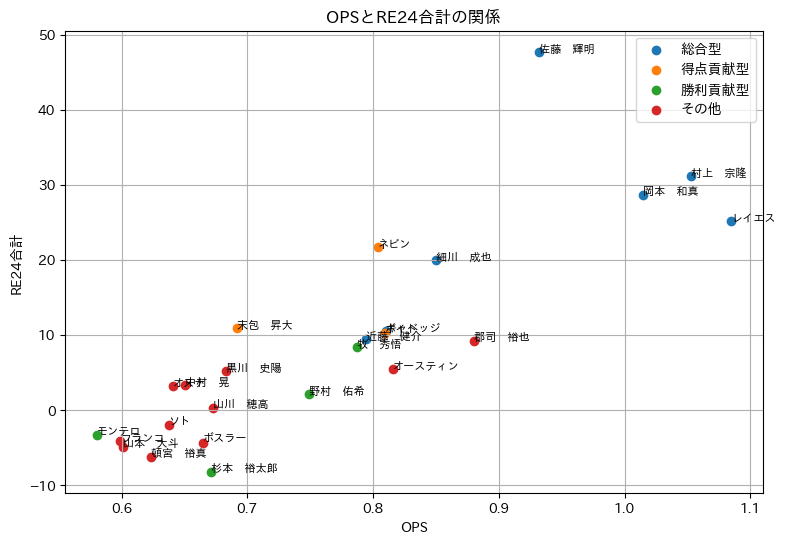

In [26]:
plt.figure(figsize=(9, 6))

for t in analysis_df["タイプ"].unique():
    data = analysis_df[analysis_df["タイプ"] == t]
    plt.scatter(data["OPS"], data["RE24合計"], label=t)

for _, row in analysis_df.iterrows():
    plt.text(row["OPS"], row["RE24合計"], row[batter_col], fontsize=8)

plt.xlabel("OPS")
plt.ylabel("RE24合計")
plt.title("OPSとRE24合計の関係")
plt.legend()
plt.grid(True)
plt.show()


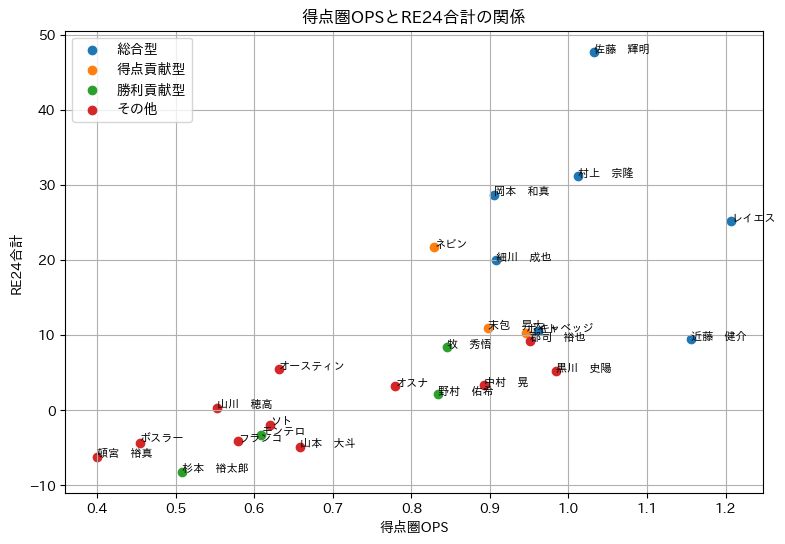

In [28]:
plt.figure(figsize=(9, 6))

for t in analysis_df["タイプ"].unique():
    data = analysis_df[analysis_df["タイプ"] == t]
    plt.scatter(data["得点圏OPS"], data["RE24合計"], label=t)

for _, row in analysis_df.iterrows():
    plt.text(row["得点圏OPS"], row["RE24合計"], row[batter_col], fontsize=8)

plt.xlabel("得点圏OPS")
plt.ylabel("RE24合計")
plt.title("得点圏OPSとRE24合計の関係")
plt.legend()
plt.grid(True)
plt.show()

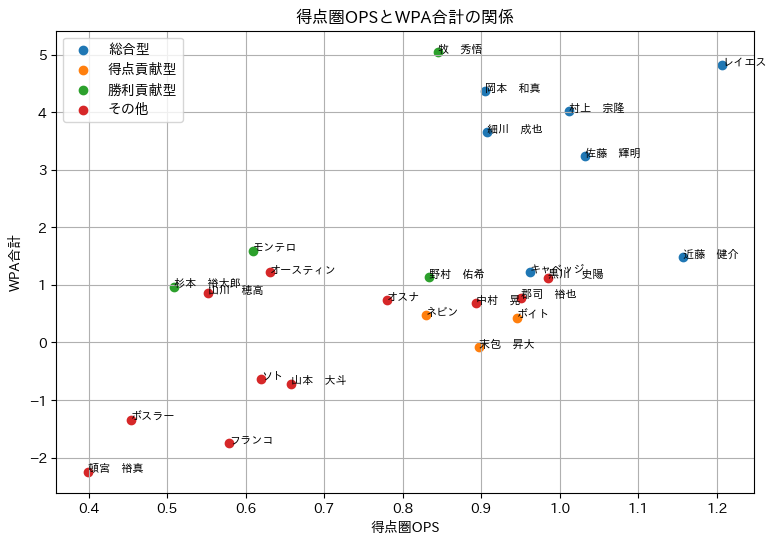

In [29]:
plt.figure(figsize=(9, 6))

for t in analysis_df["タイプ"].unique():
    data = analysis_df[analysis_df["タイプ"] == t]
    plt.scatter(data["得点圏OPS"], data["WPA合計"], label=t)

for _, row in analysis_df.iterrows():
    plt.text(row["得点圏OPS"], row["WPA合計"], row[batter_col], fontsize=8)

plt.xlabel("得点圏OPS")
plt.ylabel("WPA合計")
plt.title("得点圏OPSとWPA合計の関係")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
analysis_df.to_csv("week4_ops_risp_analysis.csv", index=False, encoding="utf-8-sig")
type_ops_summary.to_csv("week4_type_ops_summary.csv", index=False, encoding="utf-8-sig")

print("保存完了")
print("week4_ops_risp_analysis.csv")
print("week4_type_ops_summary.csv")

保存完了
week4_ops_risp_analysis.csv
week4_type_ops_summary.csv
